<a href="https://colab.research.google.com/github/shivanshi-09/aggregation_python/blob/main/expert_aggregator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/pfitznerl/agregation_2025
!7z x agregation_2025/data/data.7z -oagregation_2025/data/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from logging import logProcesses
df = pd.read_csv('agregation_2025/data/data/donnee_t_00_48_74056001.txt', sep=';',
                 na_values = ['NA', '     NA', '   NA'])

In [6]:
expert_cols = ['raw.aro', 'mos.aro', 'raw.arp', 'mos.arp', 'raw.cep', 'mos.cep']
expert_cols_pearp = expert_cols + ['Q10', 'Q20', 'Q50', 'Q70', 'Q90']
y = df['obs.t'].values
experts = df[expert_cols].values
experts_pearp = df[expert_cols_pearp].values

def prepare(experts):
  experts = experts.astype(float)
  awake = (~np.isnan(experts)).astype(float)
  experts = np.nan_to_num(experts, nan =0.0)
  return experts, awake

experts, awake = prepare(experts)
experts_pearp, awake_pearp = prepare(experts_pearp)


In [7]:
def squared_loss(y_pred, y_true):
  return (y_pred - y_true)**2
def squared_loss_grad(y_pred, y_true):
  return 2*(y_pred - y_true)
def rmse(y_pred, y_true):
  return np.sqrt(np.mean((y_pred- y_true)**2))

In [8]:
def ewa(y, experts, awake, gradient_trick = True):
  T, N = experts.shape
  C = 1.0739
  w0 = np.ones(N)
  R = np.zeros(N)
  V = 1e-300
  loss_max = 1e-300
  eta = 1.0
  pred = np.zeros(T)
  weights = np.zeros((T, N))

  for t in range (T):
      log_w = np.log(w0) + eta * R
      log_w -= np.max(log_w) # just to prevent overflow, not significant
      w = np.exp(log_w)
      w/=w.sum()
      weights[t] = w

      pred[t] = w @experts[t]
      if gradient_trick:
          grad = squared_loss_grad(pred[t], y[t])
          lexp = grad * (experts[t] - pred[t])
          lpred = 0.0

      else:
          lexp = squared_loss(experts[t], y[t])
          lpred = squared_loss(pred[t], y[t])

      r = lpred - lexp
      R+=awake[t]*r
      mean_lexp = w@lexp
      v = max(w@(lexp**2)-mean_lexp**2, 1e-300)
      V+=v
      loss_max = max(loss_max, np.max(lexp)-np.min(lexp), 1e-300)
      eta = min(1.0/loss_max, C *np.sqrt(np.log(N)/V))
      eta = min(eta, 1e2)
  return pred, weights


In [9]:
def boa (y, experts, awake, gradient_trick = True):
  T, N = experts.shape
  w0 = np.ones(N)
  R = np.zeros(N)
  R_reg = np.zeros(N)
  V = np.zeros(N)
  eta = np.zeros(N)

  pred = np.zeros(T)
  weights = np.zeros((T, N))

  for t in range(T):
    if np.any(eta>0):
      log_w = np.log(w0) + eta * R_reg
      log_w-= np.max(log_w)
      w_unnorm = awake[t] *eta *np.exp(log_w)
    else:
      w_unnorm = awake[t] *np.ones(N)

    s = w_unnorm.sum()
    w = w_unnorm/s if s>0 else awake[t]/awake[t].sum()
    weights[t] = w

    pred[t] = w@experts[t]

    if gradient_trick:
      grad = squared_loss_grad(pred[t], y[t])
      lexp = grad * (experts[t] - pred[t])
      lpred = 0.0
    else:
      lexp = squared_loss(experts[t], y[t])
      lpred = squared_loss(pred[t], y[t])

    r = awake[t]*(lpred - lexp)

    V += 2.2* r ** 2
    eta = np.minimum(np.sqrt(1.0/np.maximum(V, 1e-12)), np.exp(350))

    r_reg = r - eta * r ** 2
    r_reg =np.clip(r_reg, -1e10, 1e10)
    R+=r
    R_reg+=r_reg
  return pred, weights


In [10]:
def mlpol(y, experts, awake, gradient_trick = True):
  T, N = experts.shape
  R = np.zeros(N)
  B = 0.0
  eta = np.full(N, np.exp(700))
  pred = np.zeros(T)
  weights = np.zeros((T, N))

  for t in range(T):
    R_pos = np.maximum(R, 0.0)
    denom= eta * R_pos
    if denom.sum()>0:
      w = denom/denom.sum()
    else:
      w = np.ones(N)

    w = awake[t]*w
    w = w/w.sum()
    weights[t] = w

    pred[t] = w@experts[t]

    if gradient_trick:
      grad = squared_loss_grad(pred[t], y[t])
      lexp = grad* (experts[t] - pred[t])
      lpred = 0.0
    else:
      lexp = (experts[t]-y[t])**2
      lpred = (pred[t]- y[t])**2

    r = awake[t]*(lpred - lexp)
    R += r
    new_B = max(B, np.max(r**2))
    eta = 1.0/(1.0/eta + r** 2 + new_B - B)
    B = new_B
  return pred, weights


In [11]:
def mlprod(y, experts, awake, gradient_trick = True):
  T, N = experts.shape
  w0 = np.ones(N)
  R = np.log(w0)
  L = np.ones(N)
  maxloss = np.full(N, np.exp(-350))
  eta = np.full(N, np.exp(700))
  pred = np.zeros(T)
  weights = np.zeros((T, N))

  for t in range(T):
    w = np.minimum(np.exp(R), 1e300)
    denom = eta * w
    w = denom/denom.sum()
    w = awake[t]*w
    w = w/w.sum()
    weights[t] = w
    pred[t] = w@experts[t]
    if gradient_trick:
      grad = squared_loss_grad(pred[t], y[t])
      lexp = grad * (experts[t]- pred[t])
      lpred = 0.0
    else:
      lexp = squared_loss(experts[t], y[t])
      lpred = squared_loss(pred[t], y[t])
    r = awake[t]* (lpred - lexp)
    L = L + r **2
    maxloss = np.maximum(maxloss, np.abs(r))
    new_eta = np.minimum(1.0/(2*maxloss), np.sqrt(np.log(max(N, 2))/L))
    R = (new_eta/eta)* R + np.log(1+ awake[t]* new_eta*r)
    eta = new_eta
  return pred, weights


In [ ]:
pred_ewa, weights_ewa = ewa(y, experts, awake, gradient_trick = True)
uniform_pred = experts.mean(axis = 1)
best_expert_rmse = min(rmse(experts[:, i], y) for i in range(experts.shape[1]))

print(f"EWA: {rmse(pred_ewa, y)}")
print(f"Uniform: {rmse(uniform_pred, y):.4f}")
print(f"Best expert: {best_expert_rmse:.4f}")

pred_boa, weights_boa = boa(y, experts, awake, gradient_trick = True)
print(f"BOA: {rmse(pred_boa, y):.4f}")
pred_mlpol, weights_mlpol = mlpol(y, experts, awake, gradient_trick = True)
print(f"MLPOL: {rmse(pred_mlpol, y):.4f}")
pred_mlprod, weights_mlprod = mlprod(y, experts, awake, gradient_trick = True)
print(f"MLPROD: {rmse(pred_mlprod, y):.4f}")


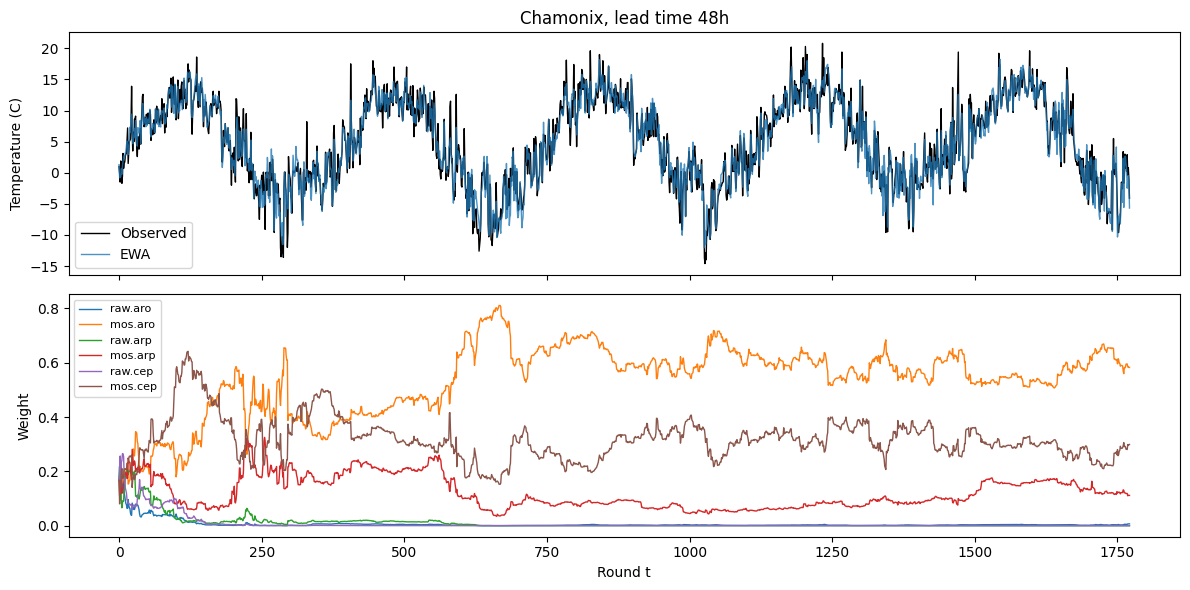

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex = True)
axes[0].plot(y, label = 'Observed', color = 'black', lw = 1)
axes[0].plot(pred_ewa, label = 'EWA', lw = 1, alpha = 0.8)
axes[0].set_ylabel('Temperature (C)')
axes[0].legend()
axes[0].set_title('Chamonix, lead time 48h')

for i, name in enumerate(expert_cols):
  axes[1].plot(weights_ewa[:, i], label = name, lw = 1)
axes[1].set_ylabel('Weight')
axes[1].set_xlabel('Round t')
axes[1].legend(fontsize = 8)
plt.tight_layout()
plt.show()

In [14]:
import glob
files = glob.glob('agregation_2025/data/data/donnee_t_00_*.txt')
results= []
results_boa =[]
results_mlpol = []
results_mlprod = []
for f in files:
  df = pd.read_csv(f, sep= ';', na_values = ['NA', '     NA', '   NA', '  NA'])
  y_f = df['obs.t'].values.astype(float)
  X_f = df[expert_cols].values
  X_f, aw_f = prepare(X_f)

  if np.all(np.isnan(y_f)) or np.all(X_f ==0):
    continue
  mask = ~np.isnan(y_f)
  y_f = y_f[mask]
  X_f = X_f[mask]
  aw_f = aw_f[mask]
  if len(y_f) == 0:
    continue

  pred_f, _ = ewa(y_f, X_f, aw_f, gradient_trick = True)
  pred_b_f, _ = boa(y_f, X_f, aw_f, gradient_trick= True)
  pred_mlpol, _ = mlpol(y_f, X_f, aw_f, gradient_trick = True)
  pred_mlprod, _ = mlprod(y_f, X_f, aw_f, gradient_trick = True)

  r = rmse(pred_f, y_f)
  r1 = rmse(pred_b_f, y_f)
  r2 = rmse(pred_mlpol, y_f)
  r3 = rmse(pred_mlprod, y_f)
  if not np.isnan(r):
    results.append(r)
  if not np.isnan(r1):
    results_boa.append(r1)
  if not np.isnan(r2):
    results_mlpol.append(r2)
  if not np.isnan(r3):
    results_mlprod.append(r3)
print(f"Files used: {len(results)}")
print(f"EWA avg RMSE across all files: {np.mean(results):.4f}")
print(f"BOA avg RMSE across all files: {np.mean(results_boa):.4f}")
print(f"MLpol avg RMSE across all files: {np.mean(results_mlpol):.4f}")
print(f"MLProd avg RMSE across all files: {np.mean(results_mlprod):4f}")

Files used: 627
EWA avg RMSE across all files: 1.2347
BOA avg RMSE across all files: 1.1948
MLpol avg RMSE across all files: 1.1951
MLProd avg RMSE across all files: 1.197291


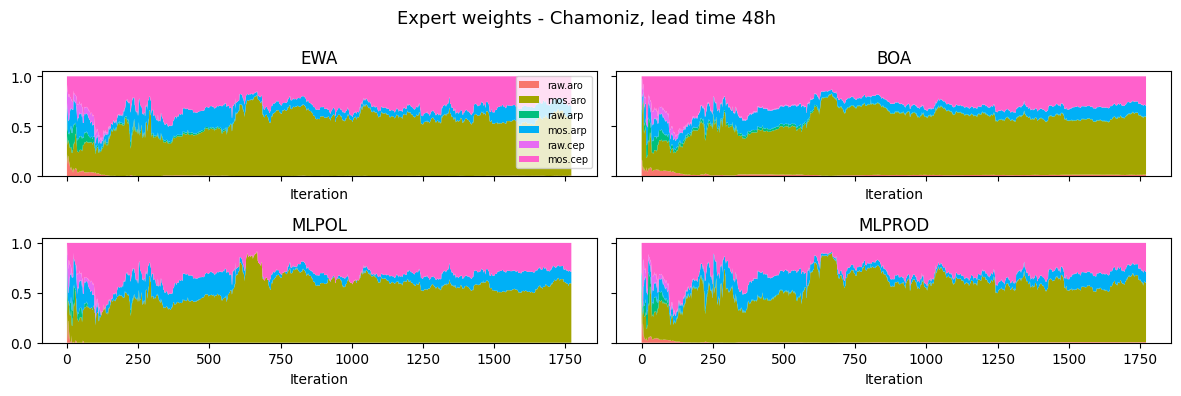

In [15]:
df_chx = pd.read_csv('agregation_2025/data/data/donnee_t_00_48_74056001.txt',
                     sep=';', na_values=['NA', '   NA', ' NA'])
y_chx = df_chx['obs.t'].values.astype(float)
X_chx = df_chx[expert_cols].values
X_chx, aw_chx = prepare(X_chx)

mask = ~np.isnan(y_chx)
y_chx = y_chx[mask]
X_chx = X_chx[mask]
aw_chx = aw_chx[mask]

pred__ewa_chx, weights_ewa_chx = ewa(y_chx, X_chx, aw_chx, gradient_trick = True)
pred__boa_chx, weights_boa_chx = boa(y_chx, X_chx, aw_chx, gradient_trick = True)
pred__mlpol_chx, weights_mlpol_chx = mlpol(y_chx, X_chx, aw_chx, gradient_trick = True)
pred__mlprod_chx, weights_mlprod_chx = mlprod(y_chx, X_chx, aw_chx, gradient_trick = True)

fig, axes = plt.subplots(2, 2, figsize=(12, 4), sharex = True, sharey = True, squeeze = False)
algo_data = [
    ('EWA', weights_ewa_chx),
    ('BOA', weights_boa_chx),
    ('MLPOL', weights_mlpol_chx),
    ('MLPROD', weights_mlprod_chx)
]
colors = ['#F8766D', '#A3A500', '#00BF7D', '#00B0F6', '#E76BF3', '#FF61CC']

for ax, (name, w) in zip(axes.flat, algo_data):
  ax.stackplot(range(len(w)), w.T, labels = expert_cols, colors =colors)
  ax.set_title(name, fontsize = 12)
  ax.set_xlabel('Weight')
  ax.set_xlabel('Iteration')
axes[0,0].legend(fontsize = 7, loc ='upper right')
fig.suptitle('Expert weights - Chamoniz, lead time 48h', fontsize = 13)
plt.tight_layout()
plt.show()

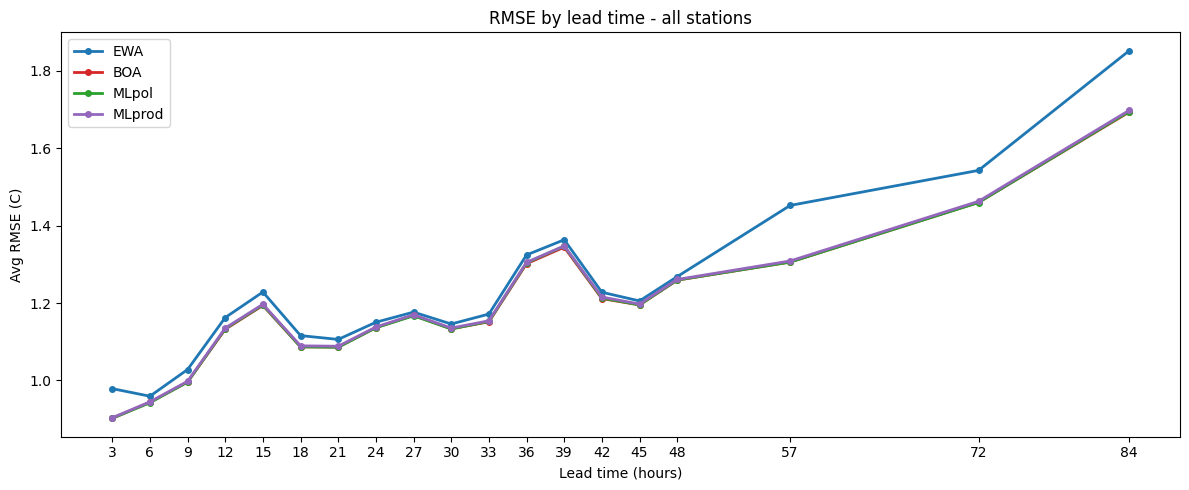

In [21]:
import re
lt_results = {'EWA':{}, 'BOA': {}, 'MLpol':{}, 'MLprod': {}}

for f in files:
  try:
    match = re.search(r'donnee_t_00_(\d+)_', f)
    if not match:
      continue
    lt = int(match.group(1))

    df = pd.read_csv(f, sep= ';', na_values = ['NA', '     NA', '   NA', '  NA'])
    y_f = df['obs.t'].values.astype(float)
    X_f = df[expert_cols].values
    X_f, aw_f = prepare(X_f)

    mask = ~np.isnan(y_f)
    y_f = y_f[mask]
    X_f = X_f[mask]
    aw_f = aw_f[mask]

    if len(y_f) == 0:
      continue

    for name, fn in [('EWA', ewa), ('BOA', boa), ('MLpol', mlpol), ('MLprod', mlprod)]:
      pred_f, _ = fn(y_f, X_f, aw_f, gradient_trick = True)
      r = rmse(pred_f, y_f)
      if not np.isnan(r):
        lt_results[name].setdefault(lt, []).append(r)
  except Exception as e:
    continue

all_lead_times = sorted(list(set(lt for algo_data in lt_results.values() for lt in algo_data.keys())))

if not all_lead_times:
    print("No valid lead times found to plot.")
else:
    fig, ax = plt.subplots(figsize =(12, 5))
    colors = {'EWA': '#1f77b4', 'BOA': '#d62728', 'MLpol': '#2ca02c', 'MLprod': '#9467bd'}

    for name in ['EWA', 'BOA', 'MLpol', 'MLprod']:
      means = [np.mean(lt_results[name].get(lt, [np.nan])) for lt in all_lead_times]
      valid_means = [m for m in means if not np.isnan(m)]
      valid_lts = [lt for lt, m in zip(all_lead_times, means) if not np.isnan(m)]

      if valid_lts:
        ax.plot(valid_lts, valid_means, label = name, color =colors[name], lw = 2, marker = 'o', markersize = 4)

    ax.set_xlabel('Lead time (hours)')
    ax.set_ylabel('Avg RMSE (C)')
    ax.set_title('RMSE by lead time - all stations')
    ax.set_xticks(all_lead_times)
    ax.legend()
    plt.tight_layout()
    plt.show()